# Task 5

## Import

In [4]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve_triangular 
from scipy.sparse import csc_matrix, tril
import scipy.linalg as la

import sys
print(sys.version)

from sksparse.cholmod import cholesky
print("scikit-sparse importato correttamente")

import subprocess                   # Library to call cpp executables
import matplotlib.pyplot as plt     # Library for spy
import time

3.11.16 | packaged by conda-forge | (main, Aug 21 2026, 22:37:11) [MSC v.1944 64 bit (AMD64)]
scikit-sparse importato correttamente


## Metodi per i tasks precedenti

Definisco un metodo che chiami i task precedenti.

In [5]:
def esecuzioneTasks12(N=32):
    executables = [
        ["../Task1/main.exe", f"{N}"],
        ["../Task2/main.exe"]
    ]
    for executable in executables:
        result = subprocess.run(executable)
        if result.returncode != 0:
            print(f"[{executable[0]}] returncode: {result.returncode}")

print("coords:", len(np.loadtxt("../FileGenerati/coords.txt")))
print("ordering:", len(np.loadtxt("../FileGenerati/ordering.txt")))


def esecuzioneTask3(N=32, usaOrdering=0):
    result = subprocess.run(
        ["../Task3/main.exe", f"{N}", f"{usaOrdering}"],
        capture_output=True,
        text=True
    )
    if result.returncode != 0 or result.stderr:
        print(f"[Task3] stderr: {result.stderr}")


# Definiamo la funzione my_cholesky come indicato nelle specifiche
def my_cholesky(A):
    # -A è definita positiva 
    neg_A = -A
    factor = cholesky(neg_A, order="natural", lower=True)
    return csc_matrix(factor[0])

def esecuzioneTask4(verbose=False):
    # Tempo di inizio algoritmo
    start_time = time.time()

    # 1. Caricamento dati e modifica
    # Caricamento del vettore rhs.txt
    rhs = np.loadtxt("../FileGenerati/rhs.txt")
    num_incognite = len(rhs)
    if verbose:
        print(f"Dimensioni del vettore rhs: {num_incognite}")

    # Caricamento della matrice sparsa A.txt
    dati_A = np.loadtxt("../FileGenerati/A.txt")
    righe = dati_A[:, 0].astype(int)
    colonne = dati_A[:, 1].astype(int)
    valori = dati_A[:, 2]
    if verbose:
        print(f"Dimensioni della matrice A: {dati_A.shape}")

    # Costruzione della matrice sparsa A in formato COO
    A_coo = sp.coo_matrix((valori, (righe, colonne)), shape=(num_incognite, num_incognite))

    # Conversione della matrice A in formato CSC (Compressed Sparse Column)
    A_csc = A_coo.tocsc()
    if verbose:
        print(f"Matrice A convertita con successo in formato CSC ({A_csc.shape[0]}x{A_csc.shape[1]}).")

    # 2. Fattorizzazione di Cholesky: -A = L * L^T
    # Eseguiamo la fattorizzazione di Cholesky per ottenere la matrice L
    L = my_cholesky(A_csc)
    if verbose:
        print("Fattorizzazione di Cholesky -A = L * L^T eseguita con successo.")
        print(f"Dimensione del fattore L: {L.shape}")

    # Nota: Dato che fattorizziamo -A, trasformiamo l'equazione A * u = rhs in (-A) * u = -rhs
    b = -rhs

    # 3a. Risoluzione del sistema triangolare inferiore L * y = b
    y = spsolve_triangular(L, b, lower=True)

    # 3b. Risoluzione del sistema triangolare superiore L^T * u = y
    L_T = L.transpose().tocsc()
    u = spsolve_triangular(L_T, y, lower=False)

    # Tempo di fine algoritmo
    end_time = time.time()

    if verbose:
        print("Sistema risolto con successo!\n")

    # 4. Verifica della soluzione ed Errore di Residuo
    residuo = np.linalg.norm(A_csc.dot(u) - rhs)
    if verbose:
        print(f"Norma del residuo ||A*u - rhs||: {residuo:.2e}")

        print("\nPrime componenti della soluzione approssimata u:")
        for idx, val in enumerate(u[:min(9, len(u))]):
            print(f"  u[{idx}] = {val:.6f}")

    ### Risultati
    tempoPassato = end_time - start_time        # Tempo di esecuzione
    entrNonZero = L.count_nonzero()       # Numero entrate non-zero della matrice

    return [A_csc, u, residuo, tempoPassato, entrNonZero, L]

coords: 4096
ordering: 4096


Debugging

In [15]:
esecuzioneTasks12(N=32)

print("DOPO N=32")
print("coords:", len(np.loadtxt("../FileGenerati/coords.txt")))
print("ordering:", len(np.loadtxt("../FileGenerati/ordering.txt")))

DOPO N=32
coords: 1024
ordering: 1024


In [16]:
esecuzioneTasks12(N=64)

print("DOPO N=64")
print("coords:", len(np.loadtxt("../FileGenerati/coords.txt")))
print("ordering:", len(np.loadtxt("../FileGenerati/ordering.txt")))

DOPO N=64
coords: 4096
ordering: 4096


In [17]:
esecuzioneTasks12(N=32)

print("PRIMA DI TASK 3")
print("coords:", len(np.loadtxt("../FileGenerati/coords.txt")))
print("ordering:", len(np.loadtxt("../FileGenerati/ordering.txt")))

esecuzioneTask3(N=32, usaOrdering=0)

print("DOPO TASK 3")
print("A:", len(np.loadtxt("../FileGenerati/A.txt")))
print("rhs:", len(np.loadtxt("../FileGenerati/rhs.txt")))
print("ordering:", len(np.loadtxt("../FileGenerati/ordering.txt")))

PRIMA DI TASK 3
coords: 1024
ordering: 1024
DOPO TASK 3
A: 4992
rhs: 1024
ordering: 1024


In [18]:
esecuzioneTasks12(N=64)

print("PRIMA DI TASK 3")
print("coords:", len(np.loadtxt("../FileGenerati/coords.txt")))
print("ordering:", len(np.loadtxt("../FileGenerati/ordering.txt")))

esecuzioneTask3(N=64, usaOrdering=0)

print("DOPO TASK 3")
print("A:", len(np.loadtxt("../FileGenerati/A.txt")))
print("rhs:", len(np.loadtxt("../FileGenerati/rhs.txt")))
print("ordering:", len(np.loadtxt("../FileGenerati/ordering.txt")))

PRIMA DI TASK 3
coords: 4096
ordering: 4096
DOPO TASK 3
A: 20224
rhs: 4096
ordering: 4096


Test N=32, ordering 0

In [19]:
esecuzioneTasks12(N=32)
esecuzioneTask3(N=32, usaOrdering=0)

print("N=32")
print("coords:", len(np.loadtxt("../FileGenerati/coords.txt")))
print("ordering:", len(np.loadtxt("../FileGenerati/ordering.txt")))
print("rhs:", len(np.loadtxt("../FileGenerati/rhs.txt")))
print("A:", len(np.loadtxt("../FileGenerati/A.txt")))

N=32
coords: 1024
ordering: 1024
rhs: 1024
A: 4992


Test N=64, ordering 0

In [20]:
esecuzioneTasks12(N=64)
esecuzioneTask3(N=64, usaOrdering=0)

print("N=64")
print("coords:", len(np.loadtxt("../FileGenerati/coords.txt")))
print("ordering:", len(np.loadtxt("../FileGenerati/ordering.txt")))
print("rhs:", len(np.loadtxt("../FileGenerati/rhs.txt")))
print("A:", len(np.loadtxt("../FileGenerati/A.txt")))

N=64
coords: 4096
ordering: 4096
rhs: 4096
A: 20224


Test termine noto

In [21]:
rhs = np.loadtxt("../FileGenerati/rhs.txt")

print("Numero valori:", len(rhs))
print("Min:", rhs.min())
print("Max:", rhs.max())
print("Primi 10:", rhs[:10])
print("Ultimi 10:", rhs[-10:])

Numero valori: 4096
Min: -0.995277
Max: -3.79588e-09
Primi 10: [-0.995277 -0.988235 -0.976609 -0.960562 -0.940317 -0.916151 -0.888391
 -0.857404 -0.82359  -0.787373]
Ultimi 10: [-4.78862e-08 -3.68224e-08 -2.81811e-08 -2.14658e-08 -1.62735e-08
 -1.22789e-08 -9.22107e-09 -6.89204e-09 -5.12694e-09 -3.79588e-09]


Test N=32, ordering=1

In [22]:
esecuzioneTasks12(N=32)

print("PRIMA TASK 3 - N=32")
print("coords:", len(np.loadtxt("../FileGenerati/coords.txt")))
print("ordering:", len(np.loadtxt("../FileGenerati/ordering.txt")))

esecuzioneTask3(N=32, usaOrdering=1)

print("DOPO TASK 3 - N=32")
print("A:", len(np.loadtxt("../FileGenerati/A.txt")))
print("rhs:", len(np.loadtxt("../FileGenerati/rhs.txt")))
print("ordering:", len(np.loadtxt("../FileGenerati/ordering.txt")))

PRIMA TASK 3 - N=32
coords: 1024
ordering: 1024
DOPO TASK 3 - N=32
A: 4992
rhs: 1024
ordering: 1024


Test N=64, ordering=1

In [23]:
esecuzioneTasks12(N=64)

print("PRIMA TASK 3 - N=64")
print("coords:", len(np.loadtxt("../FileGenerati/coords.txt")))
print("ordering:", len(np.loadtxt("../FileGenerati/ordering.txt")))

esecuzioneTask3(N=64, usaOrdering=1)

print("DOPO TASK 3 - N=64")
print("A:", len(np.loadtxt("../FileGenerati/A.txt")))
print("rhs:", len(np.loadtxt("../FileGenerati/rhs.txt")))
print("ordering:", len(np.loadtxt("../FileGenerati/ordering.txt")))

PRIMA TASK 3 - N=64
coords: 4096
ordering: 4096
DOPO TASK 3 - N=64
A: 20224
rhs: 4096
ordering: 4096


Test ordering.txt

In [24]:
ordering = np.loadtxt("../FileGenerati/ordering.txt", dtype=int)

nuovi_indici = ordering[:, 0]
vecchi_indici = ordering[:, 1]

print("Numero righe:", len(ordering))

print("Nuovi indici:")
print("min =", nuovi_indici.min())
print("max =", nuovi_indici.max())
print("unici =", len(np.unique(nuovi_indici)))

print("Vecchi indici:")
print("min =", vecchi_indici.min())
print("max =", vecchi_indici.max())
print("unici =", len(np.unique(vecchi_indici)))

Numero righe: 4096
Nuovi indici:
min = 0
max = 4095
unici = 4096
Vecchi indici:
min = 0
max = 4095
unici = 4096


# Analisi sperimentale

In [6]:
sequence_N = [32, 64, 128]#, 256, 512, 1024]

tempiEsecuzione = {}
entrateMatrice = {}
matriceA = {}
matriceL = {}
soluzioneU = {}

# Itero per ogni N l'intero algoritmo
for ordering in [0, 1]:
    for N in sequence_N:
        print(f"Computazione per opzione {ordering} ed N = {N}")

        # Eseguo tasks 1 e 2
        start_t = time.time()
        esecuzioneTasks12(N=N)
        time_tasks12 = time.time() - start_t

        # Eseguo task 3
        start_t = time.time()
        esecuzioneTask3(N=N, usaOrdering=ordering)
        time_task3 = time.time() - start_t

# --- DIAGNOSTICA TEMPORANEA: verifica che i file appena generati abbiano la dimensione attesa ---
        rhs_check = np.loadtxt("../FileGenerati/rhs.txt")
        ordering_check = np.loadtxt("../FileGenerati/ordering.txt")
        print(f"  -> rhs.txt: {len(rhs_check)} righe (atteso: {N*N})")
        print(f"  -> ordering.txt: {ordering_check.shape[0]} righe (atteso: {N*N})")
        # --- FINE DIAGNOSTICA ---

        # Eseguo task 4
        [A, u, residuo, time_task4, entrNonZero, L] = esecuzioneTask4()

        # Salvo i dati
        tempiEsecuzione[(N,ordering)] = [time_tasks12, time_task3, time_task4]
        entrateMatrice[(N,ordering)] = entrNonZero
        matriceA[(N,ordering)] = A
        matriceL[(N,ordering)] = L
        soluzioneU[(N,ordering)] = u

Computazione per opzione 0 ed N = 32
  -> rhs.txt: 1024 righe (atteso: 1024)
  -> ordering.txt: 1024 righe (atteso: 1024)
Computazione per opzione 0 ed N = 64
  -> rhs.txt: 4096 righe (atteso: 4096)
  -> ordering.txt: 4096 righe (atteso: 4096)
Computazione per opzione 0 ed N = 128
  -> rhs.txt: 16384 righe (atteso: 16384)
  -> ordering.txt: 16384 righe (atteso: 16384)
Computazione per opzione 1 ed N = 32
  -> rhs.txt: 1024 righe (atteso: 1024)
  -> ordering.txt: 1024 righe (atteso: 1024)
Computazione per opzione 1 ed N = 64
  -> rhs.txt: 4096 righe (atteso: 4096)
  -> ordering.txt: 4096 righe (atteso: 4096)
Computazione per opzione 1 ed N = 128
  -> rhs.txt: 16384 righe (atteso: 16384)
  -> ordering.txt: 16384 righe (atteso: 16384)


# Tempi di esecuzione

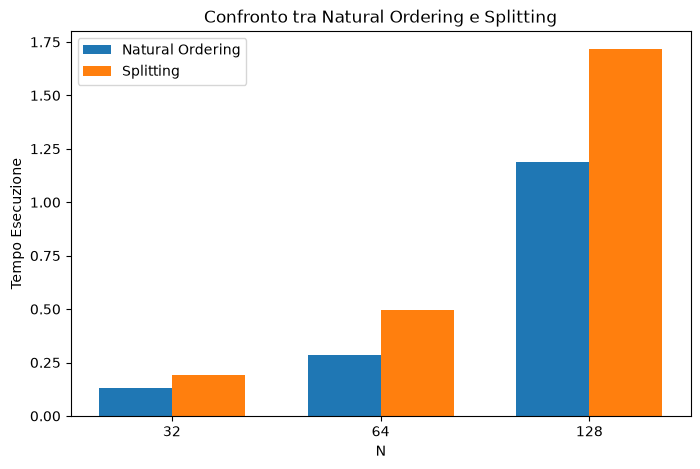

In [7]:
labels = sequence_N
values1 = [tempiEsecuzione[(N,0)][0]+tempiEsecuzione[(N,0)][2] for N in sequence_N]
values2 = [tempiEsecuzione[(N,1)][0]+tempiEsecuzione[(N,1)][1]+tempiEsecuzione[(N,1)][2] for N in sequence_N]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(8,5))

ax.bar(x - width/2, values1, width, label='Natural Ordering')
ax.bar(x + width/2, values2, width, label='Splitting')
ax.set_xlabel('N')
ax.set_ylabel('Tempo Esecuzione')
ax.set_title('Confronto tra Natural Ordering e Splitting')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.show()

# Entrate non-zero

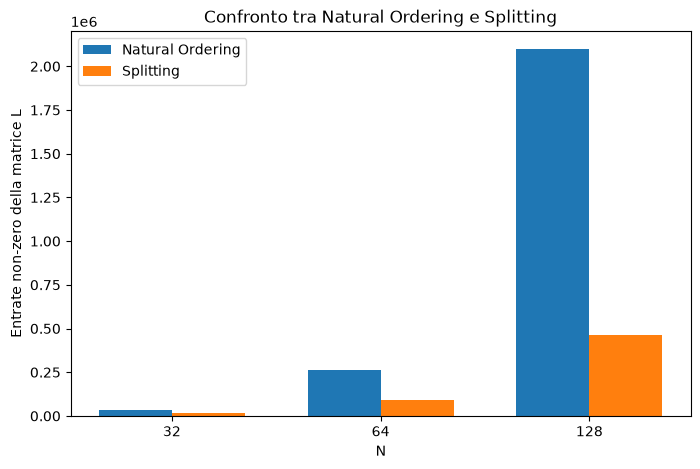

In [8]:
labels = sequence_N
values1 = [entrateMatrice[(N,0)] for N in sequence_N]
values2 = [entrateMatrice[(N,1)] for N in sequence_N]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(8,5))

ax.bar(x - width/2, values1, width, label='Natural Ordering')
ax.bar(x + width/2, values2, width, label='Splitting')
ax.set_xlabel('N')
ax.set_ylabel('Entrate non-zero della matrice L')
ax.set_title('Confronto tra Natural Ordering e Splitting')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.show()

# Plot della soluzione

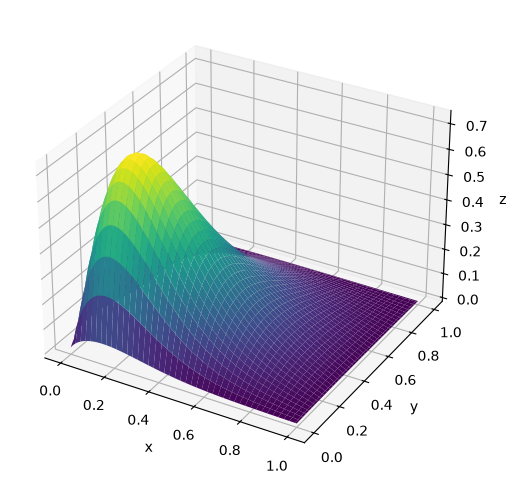

In [9]:
N = 128

x = np.linspace(0,1,N)
y = np.linspace(0,1,N)
X, Y = np.meshgrid(x, y)

plottedU = [[soluzioneU[(N,0)][x*N+y] for x in range(N)] for y in range(N)]
Z = np.array(plottedU)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

plt.show()

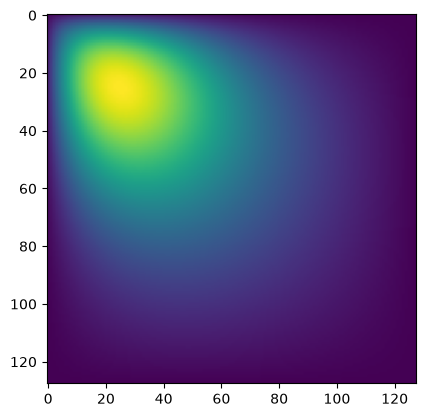

In [10]:
x = plt.imshow(Z)

# Plotting the matrices

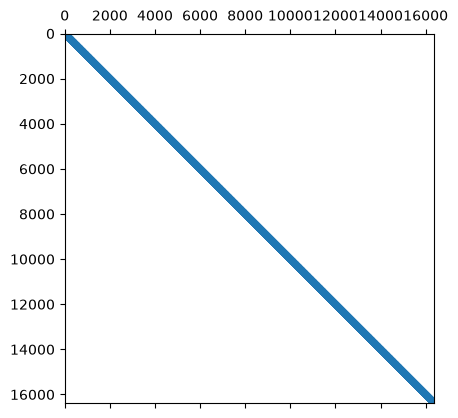

In [11]:
# Senza riordinamento
x = plt.spy(matriceA[(128,0)], marker = '.', markersize=1)

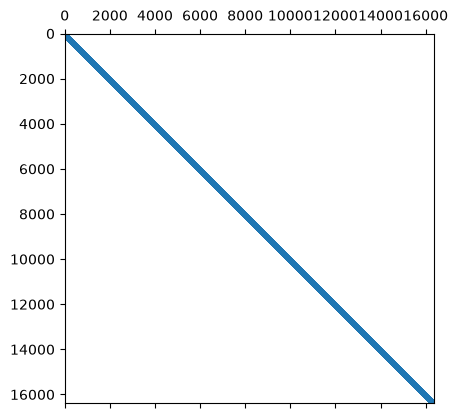

In [12]:
x = plt.spy(matriceL[(128,0)], marker = '.', markersize=1)

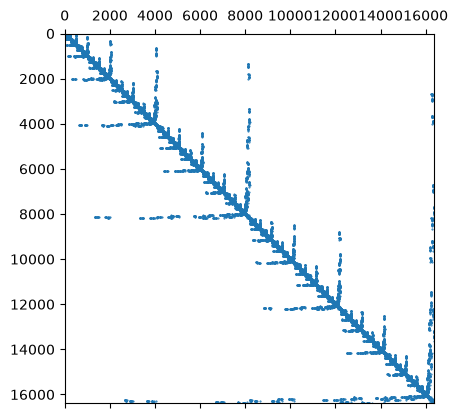

In [13]:
# Con riordinamento
y = plt.spy(matriceA[(128,1)], marker = '.', markersize=1)

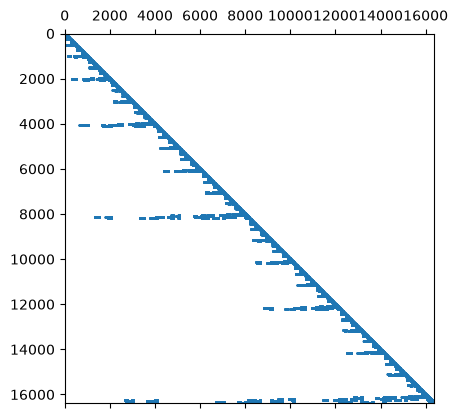

In [14]:
y = plt.spy(matriceL[(128,1)], marker = '.', markersize=1)